In [1]:
%matplotlib widget

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data
image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


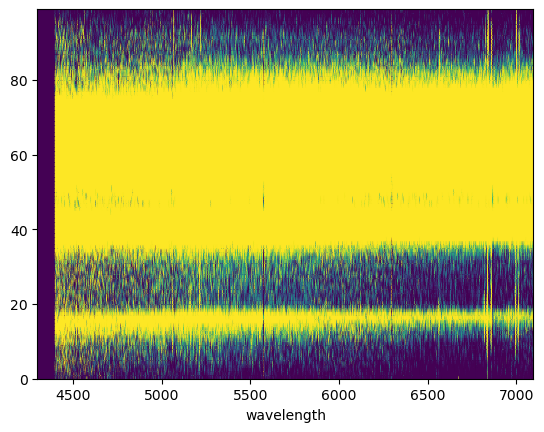

In [3]:
wavelengths = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelengths, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

z = 0.04263
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigma = seeing[0] / 2.35

Text(0.5, 1.0, 'H$\\alpha$')

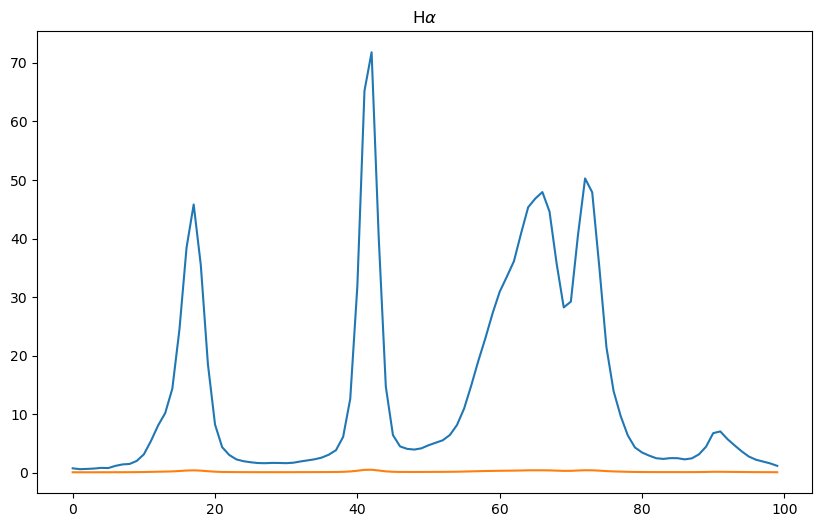

In [4]:
mask_HA = (wavelengths > l_HA-8)*(wavelengths < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [5]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def AIC(x, y, chi, nparams): #k=number of model parameter, N=number of data points
    return chi + 2*(nparams) +((2*(nparams)*((nparams)+1))/(len(y)-(nparams)-1))

def BIC(x, y, chi, nparams):
        return chi + (nparams)*np.log(len(y))
    
def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi(params_curve, radial_profile, radial_profile_error):
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2)
    print(dof)
    print(chi2_reduced)

In [6]:
df1 = pd.read_csv("One_fit.csv")
df2 = pd.read_csv("Two_fit.csv")
df3 = pd.read_csv("Three_fit.csv")
df4 = pd.read_csv("Four_fit.csv")
df5 = pd.read_csv("Five_fit.csv")
df6 = pd.read_csv("Six_fit.csv")

In [7]:
df1['Component 1']

0     2.3612
1    33.9451
2     2.0102
3    65.1220
Name: Component 1, dtype: float64

In [8]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params) 
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out
chi(df1['Component 1'], radial_profile_HA, radial_profile_error_HA)

131530.87459539916
96
1370.113277035408


In [9]:
df2

,Unnamed: 0,Component 1,Component 2
0,I_e,0.4227,8.8161
1,r_e,22.3105,13.3191
2,n,3.8564,1.1266
3,x_0,16.7220,65.3922


In [10]:
def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8])
        )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

all_params = np.concatenate([df2['Component 1'].values, df2['Component 2'].values])
chi(all_params, radial_profile_HA, radial_profile_error_HA)

80631.71639252048
92
876.4316999187009


Chi quadro ridotto:  [1370.11327301  876.43169573  228.57754605  119.92399542   34.23384236
   30.14120385   23.91545622]


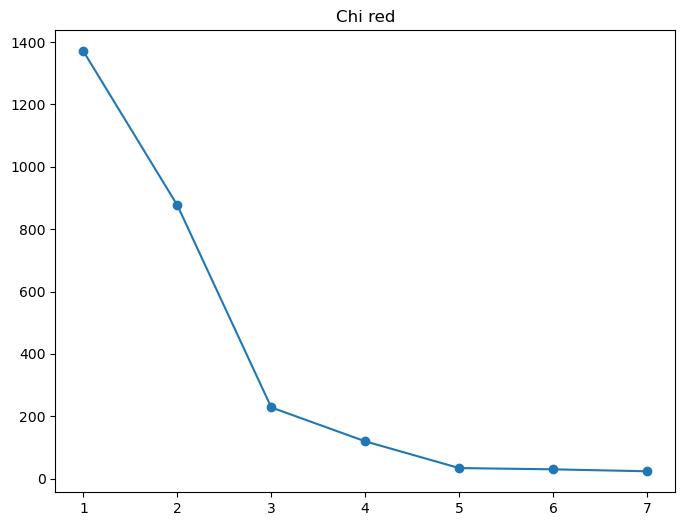

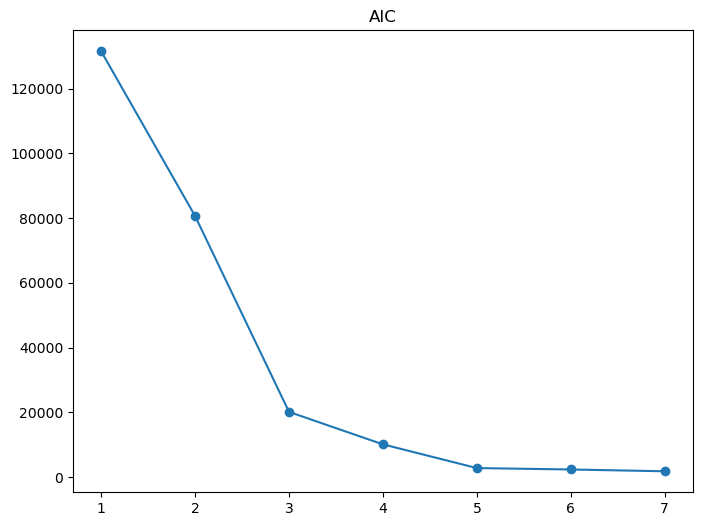

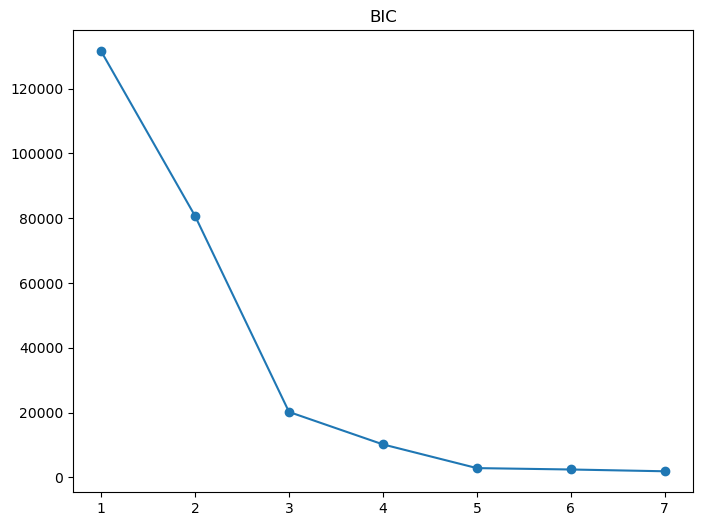

In [17]:
chi2 = np.loadtxt('Reduced_chi')
nparams = [4, 8, 12, 16, 20, 24, 28]
n = [1, 2, 3, 4, 5, 6, 7]
dof = np.zeros(7)
for i in range(len(nparams)):
    dof[i] = len(radial_profile_HA)-nparams[i]
plt.figure(figsize=(8,6))
plt.title('Chi red')
plt.plot(n, chi2/dof, marker = 'o')
print('Chi quadro ridotto: ', chi2/dof)

aic = np.zeros(7)
bic = np.zeros(7)
for i in range(len(chi2)):
    aic[i] = AIC(x_axes, radial_profile_HA, chi2[i], nparams[i])
    bic[i] = BIC(x_axes, radial_profile_HA, chi2[i], nparams[i])
plt.figure(figsize=(8,6))
plt.title('AIC')
plt.plot(n, aic, marker = 'o')
plt.figure(figsize=(8,6))
plt.title('BIC')
plt.plot(n, bic, marker = 'o')

Chi quadro ridotto:  [1370.11327301  876.43169573  228.57754605  119.92399542   34.23384236
   30.14120385   23.91545622]
Minimo chi quadro ridotto: 23.9155 per n=7


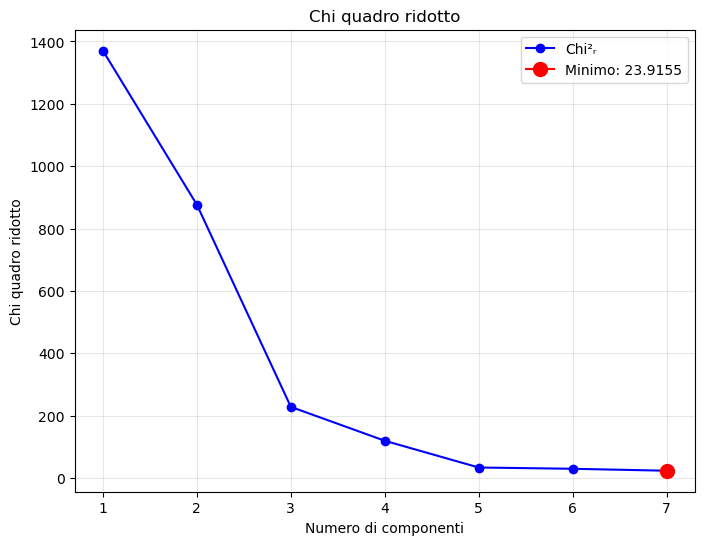

AIC values: [131539.29526166  80649.29842431  20142.41025921  10112.16983202
   2789.34029994   2354.73149273   1800.78608723]
Minimo AIC: 1800.7861 per n=7
BIC values: [131549.29488978  80668.55736822  20170.08609454  10147.29833812
   2830.81079227   2401.25557719   1850.857613  ]
Minimo BIC: 1850.8576 per n=7


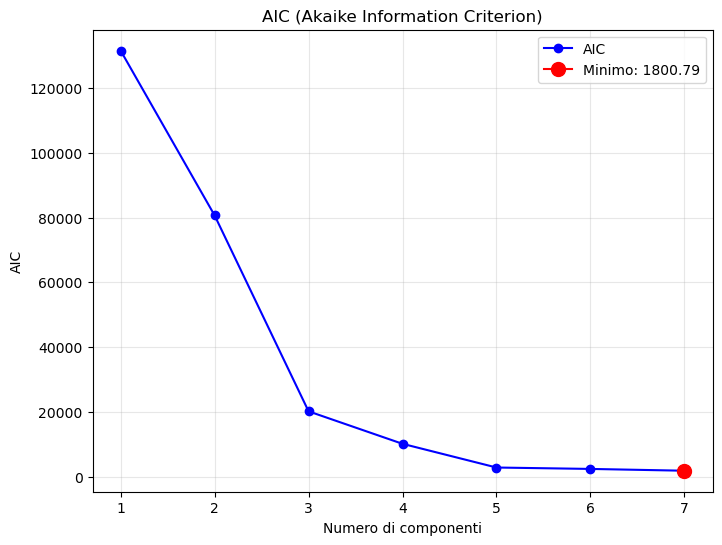

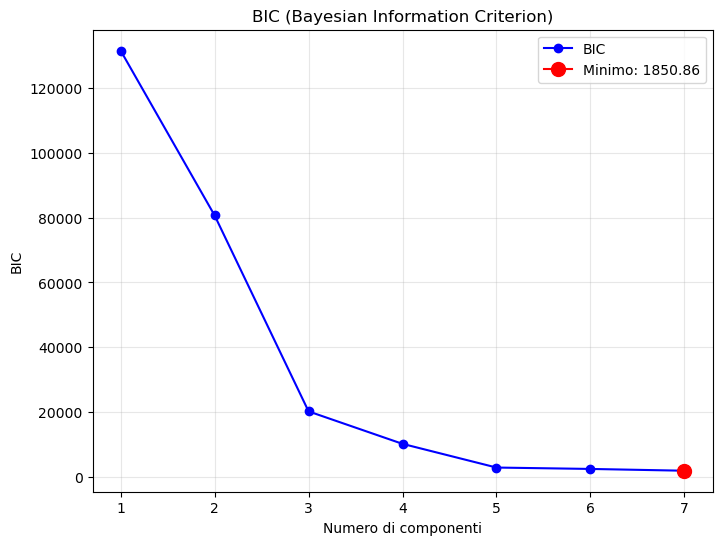

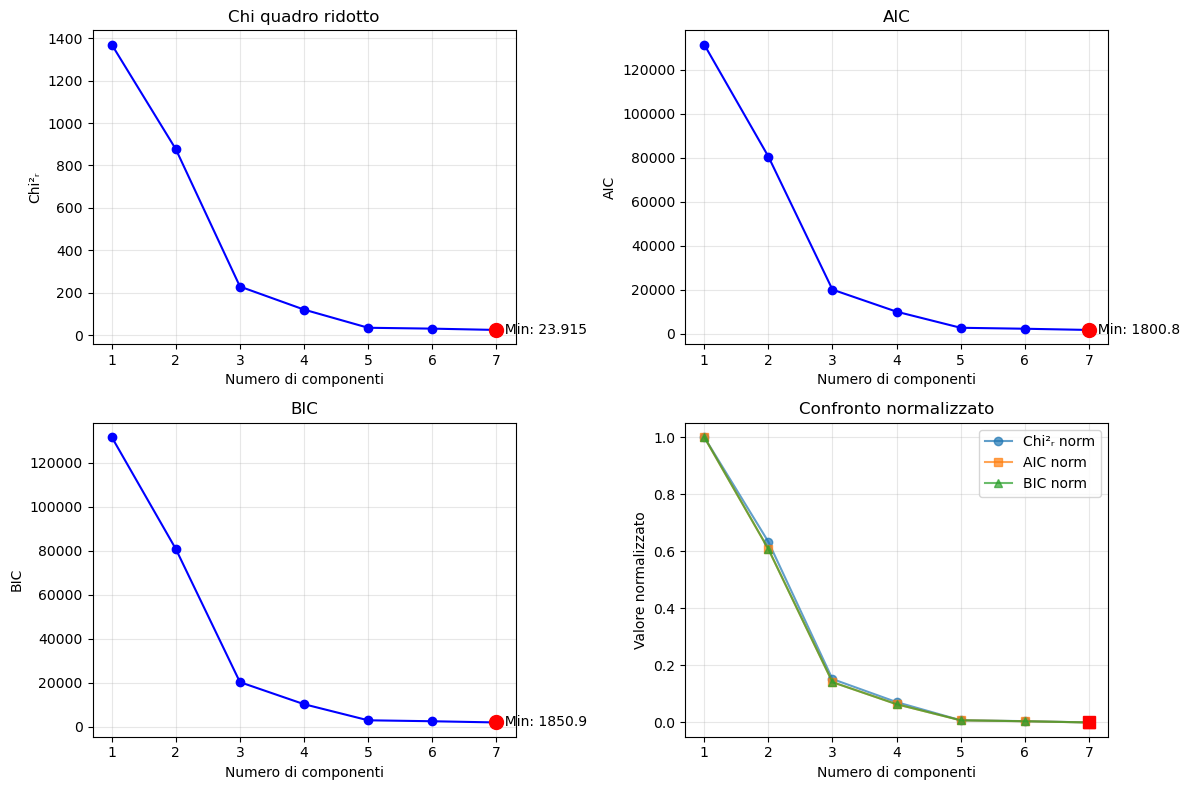


RIEPILOGO DEI RISULTATI
Chi² ridotto minimo: 23.9155 (n=7)
AIC minimo:          1800.79 (n=7)
BIC minimo:          1850.86 (n=7)

Interpretazione:
- Chi² ridotto: misura la qualità del fit
- AIC: penalizza meno l'aggiunta di parametri
- BIC: penalizza di più l'aggiunta di parametri

AIC e BIC concordano: il modello ottimale ha 7 componenti


In [19]:
chi2 = np.loadtxt('Reduced_chi')
nparams = [4, 8, 12, 16, 20, 24, 28]
n = [1, 2, 3, 4, 5, 6, 7]

# Calcolo gradi di libertà
dof = np.zeros(7)
for i in range(len(nparams)):
    dof[i] = len(radial_profile_HA) - nparams[i]

# Calcolo chi quadro ridotto
chi2_reduced = chi2 / dof

# Trova il minimo chi quadro ridotto
min_chi2_idx = np.argmin(chi2_reduced)
min_chi2_value = chi2_reduced[min_chi2_idx]
min_chi2_n = n[min_chi2_idx]

print('Chi quadro ridotto: ', chi2_reduced)
print(f'Minimo chi quadro ridotto: {min_chi2_value:.4f} per n={min_chi2_n}')

# Plot Chi quadro ridotto
plt.figure(figsize=(8, 6))
plt.title('Chi quadro ridotto')
plt.plot(n, chi2_reduced, marker='o', color='blue', label='Chi²ᵣ')
# Evidenzia il minimo in rosso
plt.plot(min_chi2_n, min_chi2_value, marker='o', color='red', 
         markersize=10, label=f'Minimo: {min_chi2_value:.4f}')
plt.xlabel('Numero di componenti')
plt.ylabel('Chi quadro ridotto')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Calcolo AIC e BIC
aic = np.zeros(7)
bic = np.zeros(7)
for i in range(len(chi2)):
    aic[i] = AIC(x_axes, radial_profile_HA, chi2[i], nparams[i])
    bic[i] = BIC(x_axes, radial_profile_HA, chi2[i], nparams[i])

# Trova i minimi
min_aic_idx = np.argmin(aic)
min_aic_value = aic[min_aic_idx]
min_aic_n = n[min_aic_idx]

min_bic_idx = np.argmin(bic)
min_bic_value = bic[min_bic_idx]
min_bic_n = n[min_bic_idx]

print(f'AIC values: {aic}')
print(f'Minimo AIC: {min_aic_value:.4f} per n={min_aic_n}')
print(f'BIC values: {bic}')
print(f'Minimo BIC: {min_bic_value:.4f} per n={min_bic_n}')

# Plot AIC
plt.figure(figsize=(8, 6))
plt.title('AIC (Akaike Information Criterion)')
plt.plot(n, aic, marker='o', color='blue', label='AIC')
# Evidenzia il minimo in rosso
plt.plot(min_aic_n, min_aic_value, marker='o', color='red', 
         markersize=10, label=f'Minimo: {min_aic_value:.2f}')
plt.xlabel('Numero di componenti')
plt.ylabel('AIC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot BIC
plt.figure(figsize=(8, 6))
plt.title('BIC (Bayesian Information Criterion)')
plt.plot(n, bic, marker='o', color='blue', label='BIC')
# Evidenzia il minimo in rosso
plt.plot(min_bic_n, min_bic_value, marker='o', color='red', 
         markersize=10, label=f'Minimo: {min_bic_value:.2f}')
plt.xlabel('Numero di componenti')
plt.ylabel('BIC')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# PLOT COMBINATO per confronto
plt.figure(figsize=(12, 8))

# Subplot 1: Chi quadro ridotto
plt.subplot(2, 2, 1)
plt.title('Chi quadro ridotto')
plt.plot(n, chi2_reduced, marker='o', color='blue')
plt.plot(min_chi2_n, min_chi2_value, marker='o', color='red', markersize=10)
plt.xlabel('Numero di componenti')
plt.ylabel('Chi²ᵣ')
plt.grid(True, alpha=0.3)
plt.text(min_chi2_n, min_chi2_value, f'  Min: {min_chi2_value:.3f}', 
         verticalalignment='center', fontsize=10)

# Subplot 2: AIC
plt.subplot(2, 2, 2)
plt.title('AIC')
plt.plot(n, aic, marker='o', color='blue')
plt.plot(min_aic_n, min_aic_value, marker='o', color='red', markersize=10)
plt.xlabel('Numero di componenti')
plt.ylabel('AIC')
plt.grid(True, alpha=0.3)
plt.text(min_aic_n, min_aic_value, f'  Min: {min_aic_value:.1f}', 
         verticalalignment='center', fontsize=10)

# Subplot 3: BIC
plt.subplot(2, 2, 3)
plt.title('BIC')
plt.plot(n, bic, marker='o', color='blue')
plt.plot(min_bic_n, min_bic_value, marker='o', color='red', markersize=10)
plt.xlabel('Numero di componenti')
plt.ylabel('BIC')
plt.grid(True, alpha=0.3)
plt.text(min_bic_n, min_bic_value, f'  Min: {min_bic_value:.1f}', 
         verticalalignment='center', fontsize=10)

# Subplot 4: Tutti insieme normalizzati
plt.subplot(2, 2, 4)
plt.title('Confronto normalizzato')
# Normalizza i valori per il confronto
chi2_norm = (chi2_reduced - np.min(chi2_reduced)) / (np.max(chi2_reduced) - np.min(chi2_reduced))
aic_norm = (aic - np.min(aic)) / (np.max(aic) - np.min(aic))
bic_norm = (bic - np.min(bic)) / (np.max(bic) - np.min(bic))

plt.plot(n, chi2_norm, marker='o', label='Chi²ᵣ norm', alpha=0.7)
plt.plot(n, aic_norm, marker='s', label='AIC norm', alpha=0.7)
plt.plot(n, bic_norm, marker='^', label='BIC norm', alpha=0.7)

# Evidenzia i minimi
plt.plot(min_chi2_n, chi2_norm[min_chi2_idx], marker='o', color='red', markersize=8)
plt.plot(min_aic_n, aic_norm[min_aic_idx], marker='s', color='red', markersize=8)
plt.plot(min_bic_n, bic_norm[min_bic_idx], marker='^', color='red', markersize=8)

plt.xlabel('Numero di componenti')
plt.ylabel('Valore normalizzato')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Riepilogo dei risultati
print("\n" + "="*50)
print("RIEPILOGO DEI RISULTATI")
print("="*50)
print(f"Chi² ridotto minimo: {min_chi2_value:.4f} (n={min_chi2_n})")
print(f"AIC minimo:          {min_aic_value:.2f} (n={min_aic_n})")
print(f"BIC minimo:          {min_bic_value:.2f} (n={min_bic_n})")
print()
print("Interpretazione:")
print("- Chi² ridotto: misura la qualità del fit")
print("- AIC: penalizza meno l'aggiunta di parametri")
print("- BIC: penalizza di più l'aggiunta di parametri")
print()
if min_aic_n == min_bic_n:
    print(f"AIC e BIC concordano: il modello ottimale ha {min_aic_n} componenti")
else:
    print(f"AIC suggerisce {min_aic_n} componenti, BIC suggerisce {min_bic_n} componenti")
    print("BIC è più conservativo e penalizza di più la complessità del modello")

In [22]:
radial_profile_error_HA

array([0.09406387, 0.09138079, 0.09223235, 0.09325778, 0.09558952,
       0.09516855, 0.10198344, 0.10614479, 0.10759947, 0.11587245,
       0.13251334, 0.16115543, 0.18885545, 0.20871927, 0.24369581,
       0.3115821 , 0.38633728, 0.4203648 , 0.3726065 , 0.27228454,
       0.19029889, 0.14843841, 0.13082932, 0.12005788, 0.11529028,
       0.11276362, 0.1109284 , 0.11063291, 0.11168722, 0.11154767,
       0.11087974, 0.1119142 , 0.1154038 , 0.1181587 , 0.12108938,
       0.12541446, 0.13252719, 0.14317122, 0.1700671 , 0.2310561 ,
       0.35660824, 0.50313234, 0.52529263, 0.39545828, 0.24711196,
       0.17367141, 0.15142141, 0.14589806, 0.14434905, 0.1470087 ,
       0.15299396, 0.1581474 , 0.16281621, 0.1729784 , 0.19068761,
       0.21573912, 0.2470679 , 0.27733508, 0.30300128, 0.327565  ,
       0.34712675, 0.36121818, 0.37371853, 0.3973638 , 0.42698315,
       0.429707  , 0.42796907, 0.41411033, 0.3717873 , 0.3323146 ,
       0.3376839 , 0.39475605, 0.43836513, 0.42873183, 0.36879